## Example of how to insert an image

![gpc_logo](gpc_logo.png)

Source: [GPC Rules and Handbook 2021](https://gpc1.org/wp-content/uploads/2021/03/GPC-Rules-and-Handbook-2021.pdf)

Notes: .png file needs to be saved to same folder as .ipynb file for the image to load. All photos sent in slack are screenshots from the above source.

# Step 1: Import

In [1]:
# Step 1: Import

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pumpkins = pd.read_csv('pumpkins.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'pumpkins.csv'

# Step 2: Explore

In [ ]:
# Step 2: Explore
print(pumpkins.shape)

(28065, 14)


In [ ]:
print(pumpkins.dtypes)

id                   object
place                object
weight_lbs           object
grower_name          object
city                 object
state_prov           object
country              object
gpc_site             object
seed_mother          object
pollinator_father    object
ott                  object
est_weight           object
pct_chart            object
variety              object
dtype: object


In [ ]:
print(pumpkins.isnull().sum())

id                       0
place                    0
weight_lbs               0
grower_name              0
city                  2779
state_prov               0
country                  0
gpc_site                 0
seed_mother           8543
pollinator_father    10307
ott                   3166
est_weight            3166
pct_chart             3166
variety              27341
dtype: int64


In [ ]:
pumpkins.describe()

,id,place,weight_lbs,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,pct_chart,variety
count,28065,28065,28065,28065,25286,28065,28065,28065,19522,17758,24899,24899,24899,724
unique,54,1851,7545,7982,3218,188,75,220,9994,4536,493,1659,226,86
top,2015-P,EXH,2.00,"Kline, Todd",Steam Mill,Other,United States,Ohio Valley Giant Pumpkin Growers Weigh-off,unknown,open,0.0,0.00,0.0,Big Zac
freq,1981,1862,49,122,292,2242,17070,759,277,2658,7736,7795,8664,349


In [ ]:
# Filter out giant pumpkins (P) and field pumpkins (F)
f_pumpkin = pumpkins[pumpkins['id'].str.contains('F')]
p_pumpkin = pumpkins[pumpkins['id'].str.contains('P')]

In [ ]:
# Stack giant pumpkin and field pumpkin data into big_pumpkin,
# check for null values
big_pumpkin = pd.concat([f_pumpkin, p_pumpkin], ignore_index=True).copy()
big_pumpkin.isnull().sum()

id                       0
place                    0
weight_lbs               0
grower_name              0
city                  1836
state_prov               0
country                  0
gpc_site                 0
seed_mother           5477
pollinator_father     6378
ott                      0
est_weight               0
pct_chart                0
variety              18721
dtype: int64

In [ ]:
# Add year and type columns
big_pumpkin['year'] = big_pumpkin['id'].str[0:4]
big_pumpkin['type'] = big_pumpkin['id'].str[5:6]
big_pumpkin.columns

Index(['id', 'place', 'weight_lbs', 'grower_name', 'city', 'state_prov',
       'country', 'gpc_site', 'seed_mother', 'pollinator_father', 'ott',
       'est_weight', 'pct_chart', 'variety', 'year', 'type'],
      dtype='object')

In [ ]:
# Convert year column values to datetime and keep only year
big_pumpkin['year'] = pd.to_datetime(big_pumpkin['year'])
big_pumpkin['year'] = big_pumpkin['year'].dt.year
big_pumpkin.shape

(18721, 16)

In [ ]:
# Drop id column 
big_pumpkin = big_pumpkin.drop(columns='id')

In [ ]:
# Remove rows where the weight_lbs is 'Entries'
big_pumpkin = big_pumpkin[~big_pumpkin['weight_lbs'].str.contains('Entries')]

In [ ]:
# Remove commas from weight_lbs values and convert values to float
big_pumpkin['weight_lbs'] = big_pumpkin['weight_lbs'].str.replace(',','')
big_pumpkin['weight_lbs'] = pd.to_numeric(big_pumpkin['weight_lbs'])
big_pumpkin['weight_lbs'].dtype

dtype('float64')

In [ ]:
# Remove commas from est_weight values and convert values to float
big_pumpkin['est_weight'] = big_pumpkin['est_weight'].str.replace(',','')
big_pumpkin['est_weight'] = pd.to_numeric(big_pumpkin['est_weight'])
big_pumpkin['est_weight'].dtype

dtype('float64')

In [ ]:
# Remove commas from ott values and convert values to float
big_pumpkin['ott'] = big_pumpkin['ott'].str.replace(',','')
big_pumpkin['ott'] = pd.to_numeric(big_pumpkin['ott'])
big_pumpkin['ott'].dtype

dtype('float64')

In [ ]:
# Check for null values
big_pumpkin.isnull().sum()

place                    0
weight_lbs               0
grower_name              0
city                  1836
state_prov               0
country                  0
gpc_site                 0
seed_mother           5477
pollinator_father     6378
ott                      0
est_weight               0
pct_chart                0
variety              18703
year                     0
type                     0
dtype: int64

In [ ]:
# Drop variety column
big_pumpkin = big_pumpkin.drop(columns='variety')

In [ ]:
# Rename type from F to the field pumpkin species name and
# from P to the giant pumpkin species name
big_pumpkin['type'] = big_pumpkin['type'].replace({'F':'Cucurbita pepo', 'P':'Cucurbita maxima'})

## Cucurbita maxima Growers

In [ ]:
# count of entries each year by grower for Cucurbita maxima
maxima = big_pumpkin[big_pumpkin['type'] == 'Cucurbita maxima']

growers_maxima = maxima.pivot_table(
    index='grower_name',
    columns='year',
    values='weight_lbs',
    aggfunc='count'
)

growers_maxima = growers_maxima.reset_index()

# make column that shows sum of count of entries per year by grower
growers_maxima['total_entries'] = growers_maxima.sum(axis=1, numeric_only=True)

# rename year columns to be more descriptive
growers_maxima = growers_maxima.rename(
    columns={
        2013:'2013_entries', 
        2014:'2014_entries', 
        2015:'2015_entries', 
        2016:'2016_entries', 
        2017:'2017_entries', 
        2018:'2018_entries', 
        2019:'2019_entries', 
        2020:'2020_entries', 
        2021:'2021_entries'})

In [ ]:
# mean pumpkin weight in lbs each year by grower for maxima
mean_weight_maxima = maxima.pivot_table(
    index='grower_name',
    columns='year',
    values='weight_lbs',
    aggfunc='mean'
)

mean_weight_maxima = mean_weight_maxima.reset_index()

# make column that shows mean weight of pumpkins across all years by grower
mean_weight_maxima['mean_all_years'] = mean_weight_maxima.mean(axis=1, numeric_only=True)

# rename year columns to be more descriptive
mean_weight_maxima = mean_weight_maxima.rename(
    columns={
        2013:'2013_mean_wt_lb', 
        2014:'2014_mean_wt_lb', 
        2015:'2015_mean_wt_lb', 
        2016:'2016_mean_wt_lb', 
        2017:'2017_mean_wt_lb', 
        2018:'2018_mean_wt_lb', 
        2019:'2019_mean_wt_lb', 
        2020:'2020_mean_wt_lb', 
        2021:'2021_mean_wt_lb'})

In [2]:
# max pumpkin weight in lbs each year by grower for maxima
max_weight_maxima = maxima.pivot_table(
    index='grower_name',
    columns='year',
    values='weight_lbs',
    aggfunc='max'
)

max_weight_maxima = max_weight_maxima.reset_index()

# make column that shows max weight across all years by grower
max_weight_maxima['max_all_years'] = max_weight_maxima.max(axis=1, numeric_only=True)

# rename year columns to be more descriptive
max_weight_maxima = max_weight_maxima.rename(
    columns={
        2013:'2013_max_wt_lb', 
        2014:'2014_max_wt_lb', 
        2015:'2015_max_wt_lb', 
        2016:'2016_max_wt_lb', 
        2017:'2017_max_wt_lb', 
        2018:'2018_max_wt_lb', 
        2019:'2019_max_wt_lb', 
        2020:'2020_max_wt_lb', 
        2021:'2021_max_wt_lb'})

NameError: name 'maxima' is not defined

In [3]:
# Outer merge growers_maxima and mean_weight_maxima

growers_maxima_mean = pd.merge(growers_maxima, mean_weight_maxima, on='grower_name', how='outer')
growers_maxima_mean.shape

NameError: name 'growers_maxima' is not defined

In [ ]:
# Outer merge growers_maxima_mean and max_weight_maxima

growers_maxima_mean_max = pd.merge(growers_maxima_mean, max_weight_maxima, on='grower_name', how='outer')
growers_maxima_mean_max.shape

(6499, 31)

In [5]:
# Rank Cucurbita maxima growers by highest number of total entries and show top 5

maxima_growers_ranked = growers_maxima_mean_max.sort_values('total_entries', ascending=False)
maxima_growers_ranked[['grower_name','total_entries', 'mean_all_years','max_all_years']].head(5)

NameError: name 'growers_maxima_mean_max' is not defined

In [ ]:
# Rank Cucurbita maxima growers by heaviest pumpkin entered (lbs) and show top 5
maxima_growers_heaviest = growers_maxima_mean_max.sort_values('max_all_years', ascending=False)
maxima_growers_heaviest[['grower_name','total_entries', 'mean_all_years','max_all_years']].head(5)

year,grower_name,total_entries,mean_all_years,max_all_years
1181,"Cutrupi, Stefano",21.0,1752.337037,2702.9
6148,"Willemijns, Mathias",8.0,1984.530556,2624.6
4310,"Paton, Ian & Stuart",18.0,1910.883333,2593.7
3780,"Mendi, Ruben",13.0,1730.141667,2551.9
1895,"Geddes, Steve",9.0,1850.277778,2528.0


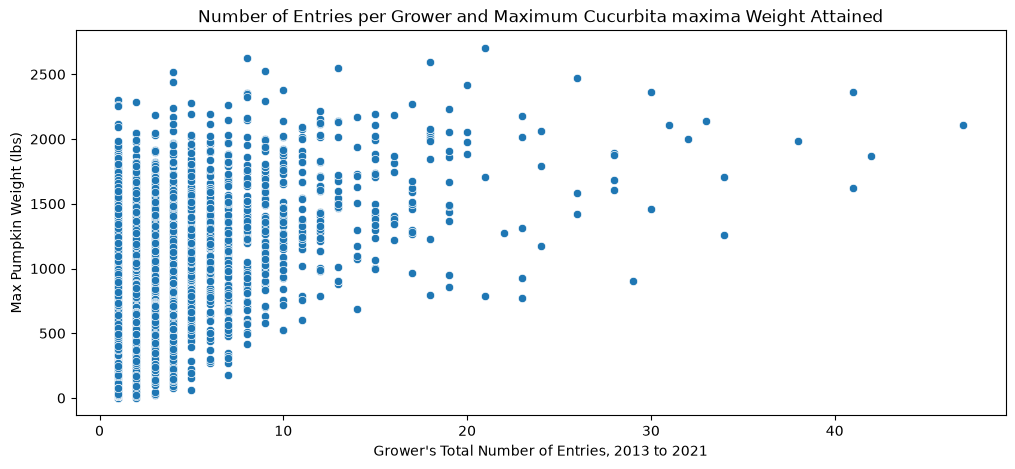

In [ ]:
# maxima growers scatterplot: total number of entries over the years and max weight ever attained

plt.figure(figsize=(12, 5))

sns.scatterplot(
    data=growers_maxima_mean_max,
    x='total_entries',
    y='max_all_years'
)
plt.title('Number of Entries per Grower and Maximum Cucurbita maxima Weight Attained')
plt.xlabel("Grower's Total Number of Entries, 2013 to 2021")
plt.ylabel("Max Pumpkin Weight (lbs)")
plt.show()

## Cucurbita pepo Growers

In [ ]:
# count of pumpkin entries each year by grower for Cucurbita pepo
pepo = big_pumpkin[big_pumpkin['type'] == 'Cucurbita pepo']

growers_pepo = pepo.pivot_table(
    index='grower_name',
    columns='year',
    values='weight_lbs',
    aggfunc='count'
)

growers_pepo = growers_pepo.reset_index()

# make column that shows sum of count of entries per year by grower
growers_pepo['total_entries'] = growers_pepo.sum(axis=1, numeric_only=True)

# rename year columns to be more descriptive
growers_pepo = growers_pepo.rename(
    columns={
        2013:'2013_entries',
        2014:'2014_entries',
        2015:'2015_entries', 
        2016:'2016_entries', 
        2017:'2017_entries', 
        2018:'2018_entries', 
        2019:'2019_entries', 
        2020:'2020_entries', 
        2021:'2021_entries'})

In [6]:
# mean pumpkin weight in lbs each year by grower for pepo
mean_weight_pepo = pepo.pivot_table(
    index='grower_name',
    columns='year',
    values='weight_lbs',
    aggfunc='mean'
)

mean_weight_pepo = mean_weight_pepo.reset_index()

# make column that shows mean weight of pumpkins across all years by grower
mean_weight_pepo['mean_all_years'] = mean_weight_pepo.mean(axis=1, numeric_only=True)

# rename year columns to be more descriptive
mean_weight_pepo = mean_weight_pepo.rename(
    columns={
        2013:'2013_mean_wt_lb', 
        2014:'2014_mean_wt_lb', 
        2015:'2015_mean_wt_lb', 
        2016:'2016_mean_wt_lb', 
        2017:'2017_mean_wt_lb', 
        2018:'2018_mean_wt_lb', 
        2019:'2019_mean_wt_lb', 
        2020:'2020_mean_wt_lb', 
        2021:'2021_mean_wt_lb'})

NameError: name 'pepo' is not defined

In [7]:
# max pumpkin weight in lbs each year by grower for pepo
max_weight_pepo = pepo.pivot_table(
    index='grower_name',
    columns='year',
    values='weight_lbs',
    aggfunc='max'
)

max_weight_pepo = max_weight_pepo.reset_index()

# make column that shows max weight across all years by grower
max_weight_pepo['max_all_years'] = max_weight_pepo.max(axis=1, numeric_only=True)

# rename year columns to be more descriptive
max_weight_pepo = max_weight_pepo.rename(
    columns={
        2013:'2013_max_wt_lb', 
        2014:'2014_max_wt_lb', 
        2015:'2015_max_wt_lb', 
        2016:'2016_max_wt_lb', 
        2017:'2017_max_wt_lb', 
        2018:'2018_max_wt_lb', 
        2019:'2019_max_wt_lb', 
        2020:'2020_max_wt_lb', 
        2021:'2021_max_wt_lb'})


NameError: name 'pepo' is not defined

In [ ]:
# Outer merge growers_pepo and mean_weight_pepo

growers_pepo_mean = pd.merge(growers_pepo, mean_weight_pepo, on='grower_name', how='outer')
growers_pepo_mean.shape

(1088, 21)

In [ ]:
# Outer merge growers_pepo_mean and max_weight_pepo

growers_pepo_mean_max = pd.merge(growers_pepo_mean, max_weight_pepo, on='grower_name', how='outer')
growers_pepo_mean_max.shape

(1088, 31)

In [ ]:
# Rank Cucurbita pepo growers by highest number of total entries and show top 5

pepo_growers_ranked = growers_pepo_mean_max.sort_values('total_entries', ascending=False)
pepo_growers_ranked[['grower_name','total_entries', 'mean_all_years','max_all_years']].head(5)

year,grower_name,total_entries,mean_all_years,max_all_years
952,"Treece, Jef",64.0,114.379153,188.5
725,"Paul, Michael",26.0,123.255952,177.0
891,"Steil, Scott",22.0,124.310884,197.5
385,"Harnica, John",21.0,102.930556,153.5
183,"Cleaview, Acres",19.0,91.580714,147.0


In [ ]:
# Rank Cucurbita pepo growers by heaviest pumpkin entered (lbs) and show top 5

pepo_growers_heaviest = growers_pepo_mean_max.sort_values('max_all_years', ascending=False)
pepo_growers_heaviest[['grower_name','total_entries', 'mean_all_years','max_all_years']].head(5)

year,grower_name,total_entries,mean_all_years,max_all_years
578,"MacKinnon, John",11.0,155.889722,211.0
1053,"Wursten, Bradley",6.0,123.162500,205.0
690,"Nesbitt, Alan",2.0,182.750000,204.5
891,"Steil, Scott",22.0,124.310884,197.5
575,"MacKinnon , John",1.0,197.000000,197.0


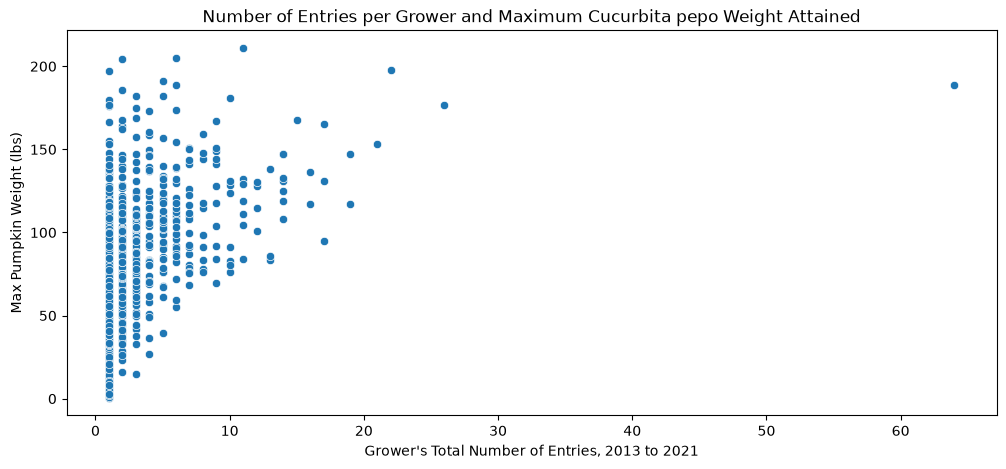

In [ ]:
# pepo growers scatterplot: total number of entries over the years and max weight ever attained

plt.figure(figsize=(12, 5))

sns.scatterplot(
    data=growers_pepo_mean_max,
    x='total_entries',
    y='max_all_years'
)
plt.title('Number of Entries per Grower and Maximum Cucurbita pepo Weight Attained')
plt.xlabel("Grower's Total Number of Entries, 2013 to 2021")
plt.ylabel("Max Pumpkin Weight (lbs)")
plt.show()